# LLM vs Human PDF Grading Analysis

Full pipeline comparing 7 LLM models against human TA grades across 3 students, 3 runs, 17 questions.

**File:** `pdf_grading_results/grading_results_with_ta_score.csv`  
**Models:** GPT-5, GPT-4o, Claude Opus, Claude Sonnet, Claude Haiku, Gemini 2.5 Pro, Gemini 2.5 Flash  
**Graders:** TA1
**Runs:** 3
**Questions:** 6 (20 subquestions total) (student needs to answer any 5 questions, 17 sub-questions attempted by students)
**Total Grades:** 72 (60 to be attempted by students)

In [84]:
# Install additional dependencies (run once)
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "pip"])
pkgs = ["pingouin", "matplotlib", "seaborn", "scipy", "statsmodels"]
for pkg in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("All dependencies installed.")


All dependencies installed.


In [85]:
import os, ast, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.stats.anova import AnovaRM
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pingouin as pg
from sklearn.metrics import cohen_kappa_score

warnings.filterwarnings("ignore")

# Plotting style
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 110

# Output directory
os.makedirs("outputs_pdf", exist_ok=True)

DATA_PATH = "pdf_grading_results/grading_results_with_ta_score.csv"
print("Libraries loaded.")


Libraries loaded.


## Phase 1 — Data Ingestion & Preparation


In [86]:
# Load CSV
df = pd.read_csv(DATA_PATH, encoding="utf-8")
print(f"Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
df.info()


Shape: (63, 10)
Memory usage: 1927.1 KB
<class 'pandas.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   pdf_id                63 non-null     int64  
 1   model                 63 non-null     str    
 2   run                   63 non-null     int64  
 3   total_score           63 non-null     float64
 4   total_points          63 non-null     float64
 5   feedback_by_question  63 non-null     str    
 6   overall_feedback      63 non-null     str    
 7   llm_call_time_taken   63 non-null     float64
 8   total_time_taken      63 non-null     float64
 9   total_grade           63 non-null     int64  
dtypes: float64(4), int64(3), str(3)
memory usage: 5.1 KB


In [87]:
# Parse JSON/dict columns safely
def safe_parse(val):
    if pd.isna(val) or val == "":
        return {}
    try:
        return json.loads(val)
    except (json.JSONDecodeError, TypeError):
        try:
            return ast.literal_eval(val)
        except Exception:
            return {}

df["feedback_parsed"] = df["feedback_by_question"].apply(safe_parse)
# df["ta_grades_parsed"] = df["ta_grades_by_question"].apply(safe_parse)

# Check uniqueness of (pdf_id, model, run)
dupe_mask = df.duplicated(subset=["pdf_id", "model", "run"])
print(f"Duplicate rows (pdf_id, model, run): {dupe_mask.sum()}")
if dupe_mask.sum():
    df = df[~dupe_mask].reset_index(drop=True)
    print("Duplicates dropped.")

print(f"\nModels ({df['model'].nunique()}):", df["model"].unique().tolist())
print(f"Students: {df['pdf_id'].nunique()} | Runs: {sorted(df['run'].unique())}")


Duplicate rows (pdf_id, model, run): 0

Models (7): ['gpt-5', 'gpt-4o', 'global.anthropic.claude-opus-4-6-v1', 'global.anthropic.claude-sonnet-4-6', 'global.anthropic.claude-haiku-4-5-20251001-v1:0', 'gemini-2.5-flash', 'gemini-2.5-pro']
Students: 3 | Runs: [np.int64(1), np.int64(2), np.int64(3)]


In [88]:
# Missing value analysis
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
print(missing_df[missing_df["missing_count"] > 0])

# Impute missing text feedback
df["overall_feedback"] = df["overall_feedback"].fillna("")
print("\nAfter imputation — remaining nulls in overall_feedback:", df["overall_feedback"].isna().sum())


Empty DataFrame
Columns: [missing_count, missing_%]
Index: []

After imputation — remaining nulls in overall_feedback: 0


## Phase 2 — Feature Engineering


In [89]:
# Single TA score is in 'total_grade' column
df["ta_score"] = df["total_grade"]   # single TA total score

# LLM vs human comparison features
df["llm_bias"]      = df["total_score"] - df["ta_score"]   # positive = LLM over-grades
df["llm_abs_error"] = df["llm_bias"].abs()
df["norm_score"]    = df["total_score"] / df["total_points"]

# Short model labels for plotting
MODEL_LABELS = {
    "gpt-5": "GPT-5",
    "gpt-4o": "GPT-4o",
    "global.anthropic.claude-opus-4-6-v1": "Claude Opus",
    "global.anthropic.claude-sonnet-4-6": "Claude Sonnet",
    "global.anthropic.claude-haiku-4-5-20251001-v1:0": "Claude Haiku",
    "gemini-2.5-pro": "Gemini 2.5 Pro",
    "gemini-2.5-flash": "Gemini 2.5 Flash",
}
df["model_label"] = df["model"].map(MODEL_LABELS)

print(df[["model_label", "ta_score", "llm_bias", "llm_abs_error", "norm_score"]].head())
print(f"\nta_score null rows: {df['ta_score'].isna().sum()}")


  model_label  ta_score  llm_bias  llm_abs_error  norm_score
0       GPT-5        55     -26.0           26.0    0.402778
1       GPT-5        55     -25.5           25.5    0.409722
2       GPT-5        55     -25.0           25.0    0.416667
3      GPT-4o        55     -23.0           23.0    0.444444
4      GPT-4o        55     -20.5           20.5    0.479167

ta_score null rows: 0


In [90]:
# Extract per-question LLM scores into long-form DataFrame
# (No per-question TA data available — only total TA grade is provided)

llm_q_rows = []
for _, row in df.iterrows():
    for q_id, qdata in row["feedback_parsed"].items():
        llm_q_rows.append({
            "pdf_id": row["pdf_id"],
            "model": row["model"],
            "model_label": row["model_label"],
            "run": row["run"],
            "question": f"Q{q_id}",
            "llm_score": qdata.get("score", np.nan),
            "max_points": qdata.get("max_points", np.nan),
        })
df_q = pd.DataFrame(llm_q_rows)

print(f"Per-question rows: {len(df_q)}")
print(f"Questions: {sorted(df_q['question'].unique())}")
df_q.head()


Per-question rows: 1260
Questions: ['Q1.1', 'Q1.10', 'Q1.11', 'Q1.12', 'Q1.2', 'Q1.3', 'Q1.4', 'Q1.5', 'Q1.6', 'Q1.7', 'Q1.8', 'Q1.9', 'Q2.1.1', 'Q2.1.2', 'Q2.2', 'Q3', 'Q4', 'Q5', 'Q6.1', 'Q6.2']


,pdf_id,model,model_label,run,question,llm_score,max_points
0,1,gpt-5,GPT-5,1,Q1.1,0.5,1.0
1,1,gpt-5,GPT-5,1,Q1.2,1.0,1.0
2,1,gpt-5,GPT-5,1,Q1.3,1.0,1.0
3,1,gpt-5,GPT-5,1,Q1.4,0.5,1.0
4,1,gpt-5,GPT-5,1,Q1.5,1.0,1.0


## Phase 3 — Descriptive Statistics


In [91]:
# Overall descriptive statistics
num_cols = ["total_score", "ta_score", "llm_bias", "llm_abs_error", "llm_call_time_taken"]
desc = df[num_cols].describe().T
desc["median"] = df[num_cols].median()
print("=== Global Descriptive Statistics ===")
display(desc[["count", "mean", "median", "std", "min", "25%", "75%", "max"]].round(2))


=== Global Descriptive Statistics ===


,count,mean,median,std,min,25%,75%,max
total_score,63.0,34.61,33.00,7.67,24.75,30.25,35.12,62.0
ta_score,63.0,55.33,55.00,1.26,54.00,54.00,57.00,57.0
llm_bias,63.0,-20.73,-23.00,7.66,-30.50,-25.12,-19.88,5.0
llm_abs_error,63.0,21.07,23.00,6.63,0.70,19.88,25.12,30.5
llm_call_time_taken,63.0,130.36,88.88,112.84,49.72,60.84,158.79,650.0


In [92]:
# Per-model summary statistics
model_stats = (
    df.groupby("model_label")
    .agg(
        n=("total_score", "count"),
        mean_score=("total_score", "mean"),
        median_score=("total_score", "median"),
        std_score=("total_score", "std"),
        mean_ta_score=("ta_score", "mean"),
        mean_bias=("llm_bias", "mean"),
        mean_abs_error=("llm_abs_error", "mean"),
        median_latency_s=("llm_call_time_taken", "median"),
    )
    .round(2)
    .sort_values("mean_abs_error")
)
print("=== Per-Model Summary (sorted by MAE) ===")
display(model_stats)


=== Per-Model Summary (sorted by MAE) ===


,n,mean_score,median_score,std_score,mean_ta_score,mean_bias,mean_abs_error,median_latency_s
model_label,,,,,,,,
Claude Haiku,9,50.26,48.6,8.85,55.33,-5.08,7.51,56.65
Gemini 2.5 Flash,9,34.28,34.0,2.37,55.33,-21.06,21.06,60.81
Gemini 2.5 Pro,9,33.89,34.0,2.18,55.33,-21.44,21.44,88.88
GPT-4o,9,32.56,32.0,1.99,55.33,-22.78,22.78,62.69
Claude Opus,9,31.94,33.0,2.08,55.33,-23.39,23.39,160.31
Claude Sonnet,9,30.61,31.0,3.43,55.33,-24.72,24.72,154.01
GPT-5,9,28.72,29.0,1.23,55.33,-26.61,26.61,226.77


In [93]:
# Per-question mean LLM scores across all models, students, and runs
q_summary = (
    df_q.groupby(["model_label", "question"])
    .agg(
        mean_llm=("llm_score", "mean"),
        std_llm=("llm_score", "std"),
        max_points=("max_points", "first"),
    )
    .round(2)
    .reset_index()
)
print("=== Per-Question Mean LLM Scores (all models) ===")
display(q_summary.pivot_table(index="question", columns="model_label",
                               values="mean_llm", aggfunc="mean").round(2))


=== Per-Question Mean LLM Scores (all models) ===


model_label,Claude Haiku,Claude Opus,Claude Sonnet,GPT-4o,GPT-5,Gemini 2.5 Flash,Gemini 2.5 Pro
question,,,,,,,
Q1.1,0.58,0.50,0.56,0.50,0.50,0.58,0.56
Q1.10,0.83,0.83,0.83,0.78,0.89,0.92,1.00
Q1.11,0.89,0.94,0.94,1.00,0.94,1.00,0.83
Q1.12,0.44,0.50,0.50,0.50,0.39,0.86,0.67
Q1.2,0.61,0.83,0.67,0.67,0.83,0.92,0.83
Q1.3,0.63,0.83,0.72,0.67,0.83,1.00,0.83
Q1.4,0.96,0.94,0.67,1.00,0.67,0.83,0.72
Q1.5,0.56,0.83,0.50,0.44,0.67,0.67,0.67
Q1.6,0.51,0.33,0.44,0.33,0.33,0.33,0.33


## Phase 4 — Visualizations


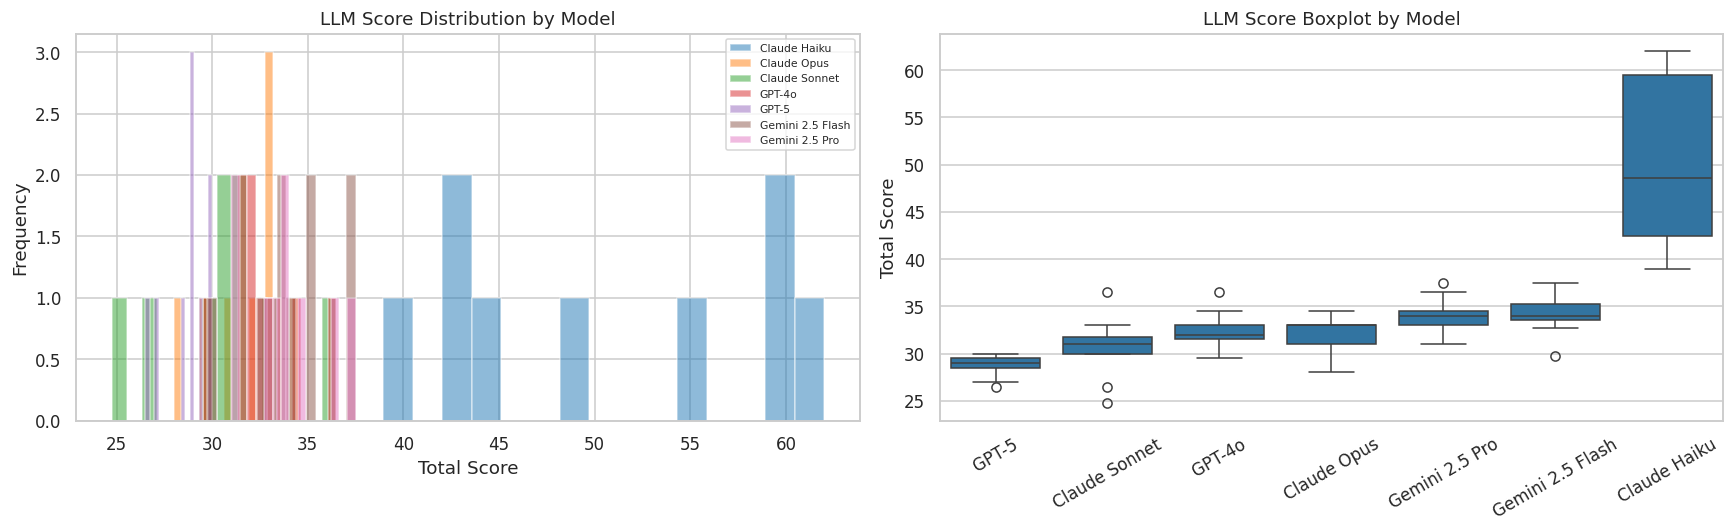

In [94]:
# 4.1 Score distribution: histogram + boxplot per model
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
for label, grp in df.groupby("model_label"):
    axes[0].hist(grp["total_score"], bins=15, alpha=0.5, label=label)
axes[0].set_title("LLM Score Distribution by Model")
axes[0].set_xlabel("Total Score")
axes[0].set_ylabel("Frequency")
axes[0].legend(fontsize=7)

# Boxplot
order = df.groupby("model_label")["total_score"].median().sort_values().index.tolist()
sns.boxplot(data=df, x="model_label", y="total_score", order=order, ax=axes[1])
axes[1].set_title("LLM Score Boxplot by Model")
axes[1].set_xlabel("")
axes[1].set_ylabel("Total Score")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("outputs_pdf/4_1_score_distributions.png", bbox_inches="tight")
plt.show()


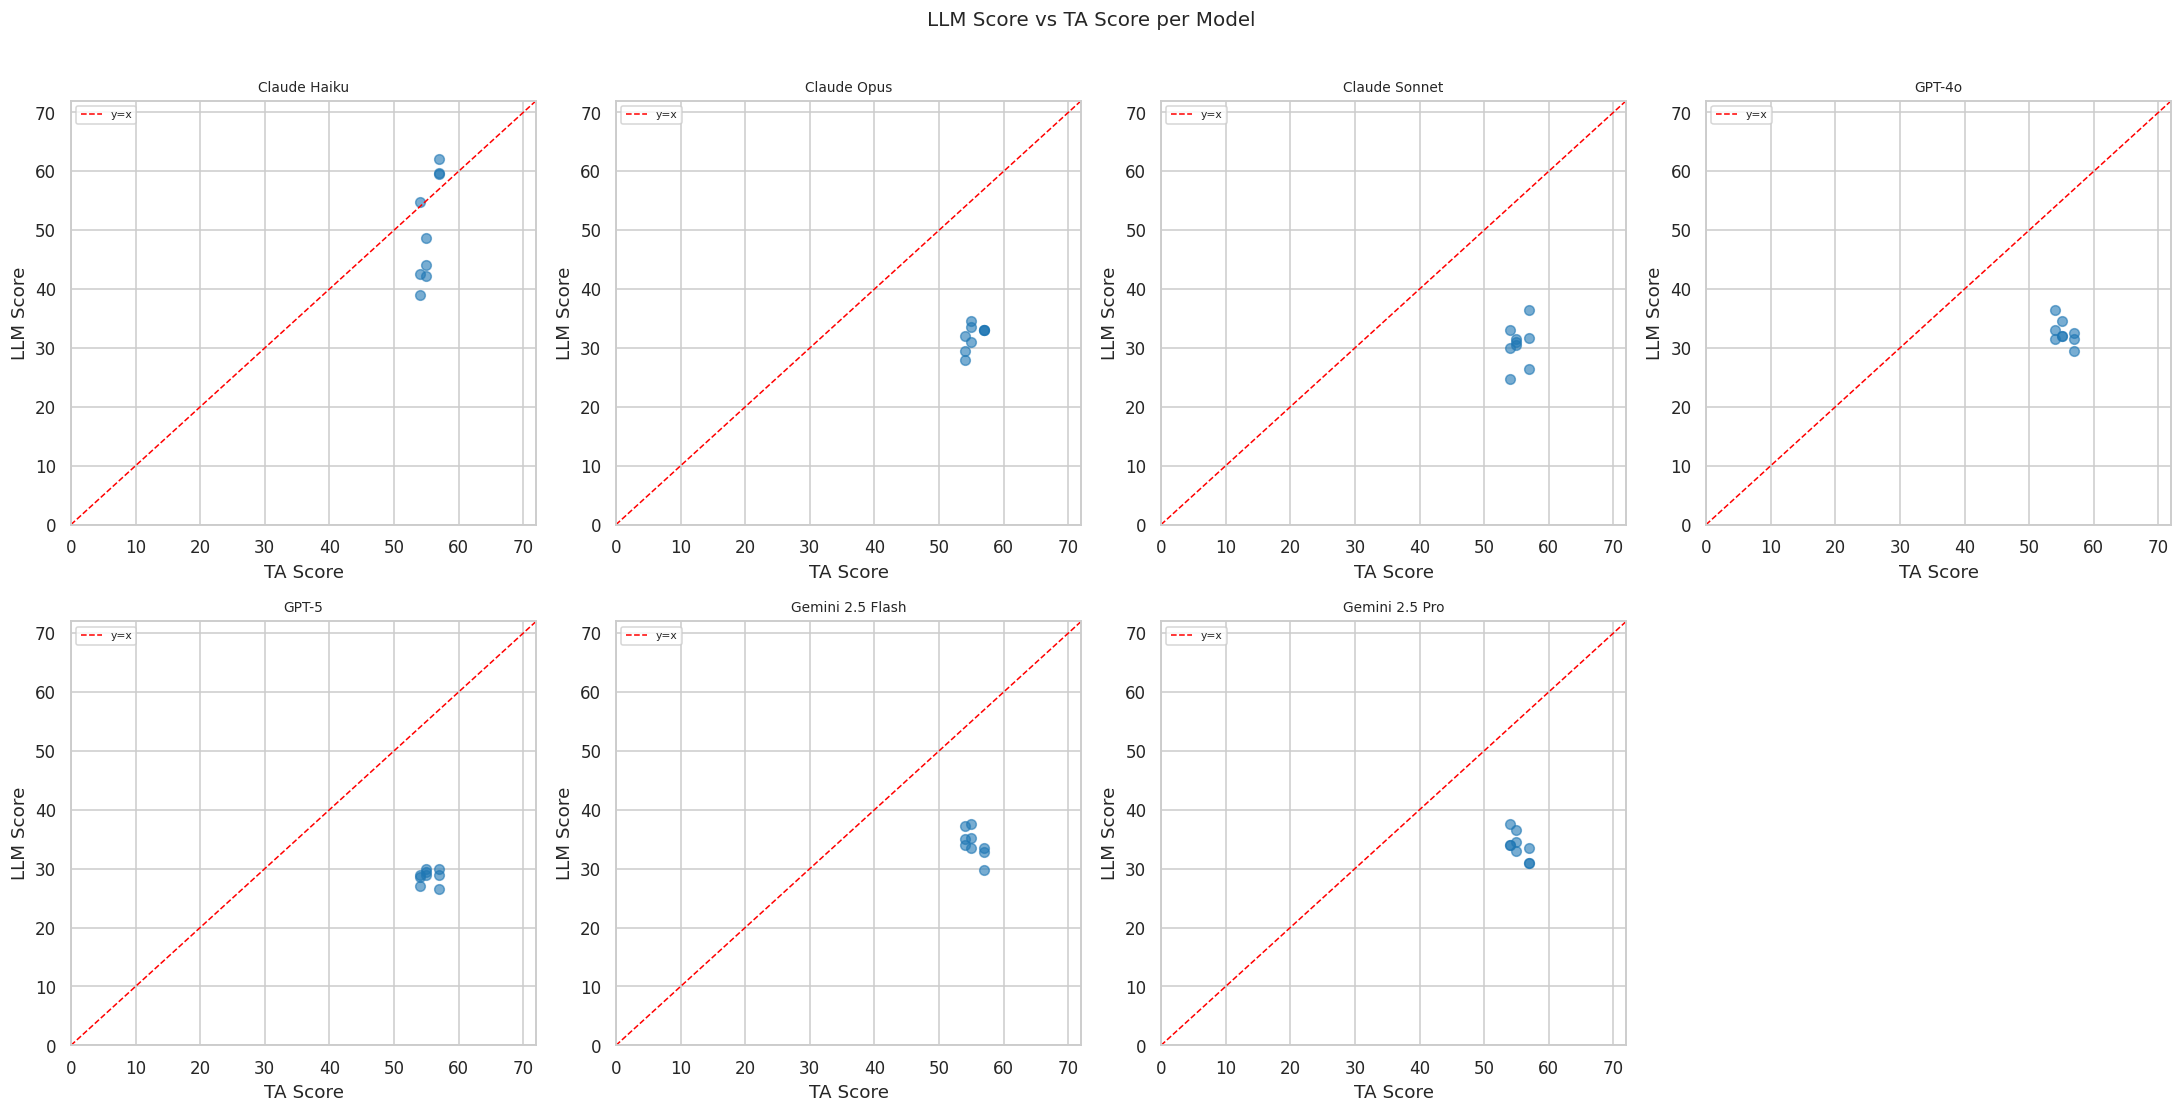

In [95]:
# 4.2 LLM score vs TA score scatter (one panel per model)
models_ordered = sorted(df["model_label"].dropna().unique())
n_models = len(models_ordered)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, mlabel in enumerate(models_ordered):
    ax = axes[i]
    sub = df[df["model_label"] == mlabel]
    ax.scatter(sub["ta_score"], sub["total_score"], alpha=0.6, s=40)
    # Identity line
    lims = [0, 72]
    ax.plot(lims, lims, "r--", linewidth=1, label="y=x")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_title(mlabel, fontsize=9)
    ax.set_xlabel("TA Score"); ax.set_ylabel("LLM Score")
    ax.legend(fontsize=7)

# Hide unused subplot
for j in range(n_models, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("LLM Score vs TA Score per Model", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("outputs_pdf/4_2_llm_vs_ta_scatter.png", bbox_inches="tight")
plt.show()


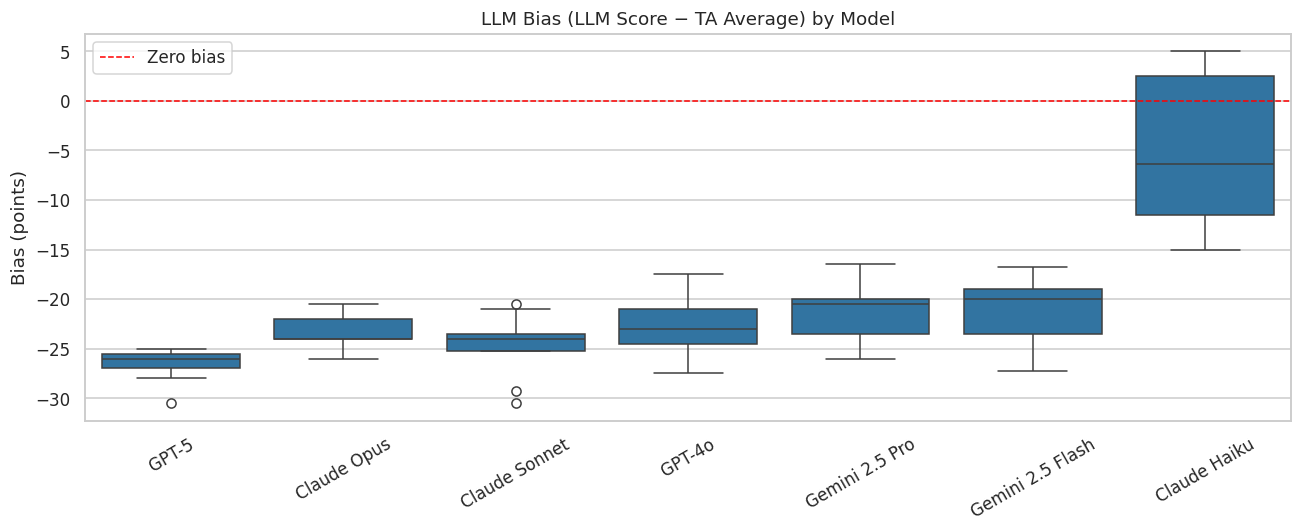

In [96]:
# 4.3 Bias (LLM - TA_avg) boxplot per model
bias_order = df.groupby("model_label")["llm_bias"].median().sort_values().index.tolist()
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x="model_label", y="llm_bias", order=bias_order, ax=ax)
ax.axhline(0, color="red", linestyle="--", linewidth=1, label="Zero bias")
ax.set_title("LLM Bias (LLM Score − TA Average) by Model")
ax.set_xlabel("")
ax.set_ylabel("Bias (points)")
ax.tick_params(axis="x", rotation=30)
ax.legend()
plt.tight_layout()
plt.savefig("outputs_pdf/4_3_bias_boxplot.png", bbox_inches="tight")
plt.show()


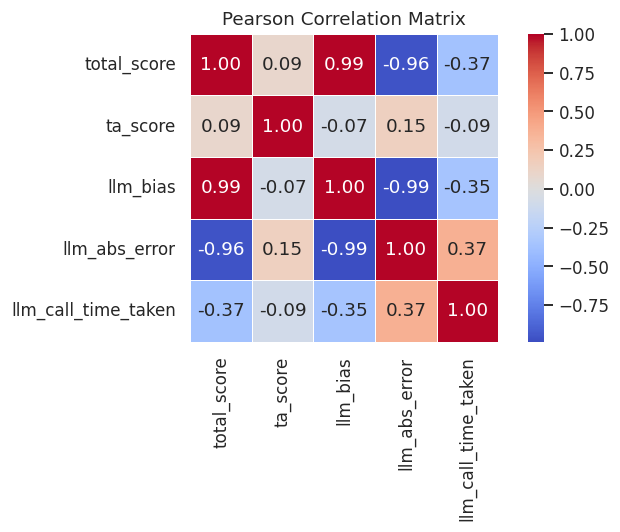

In [97]:
# 4.4 Correlation heatmap
corr_cols = ["total_score", "ta_score", "llm_bias", "llm_abs_error", "llm_call_time_taken"]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Pearson Correlation Matrix")
plt.tight_layout()
plt.savefig("outputs_pdf/4_4_correlation_heatmap.png", bbox_inches="tight")
plt.show()


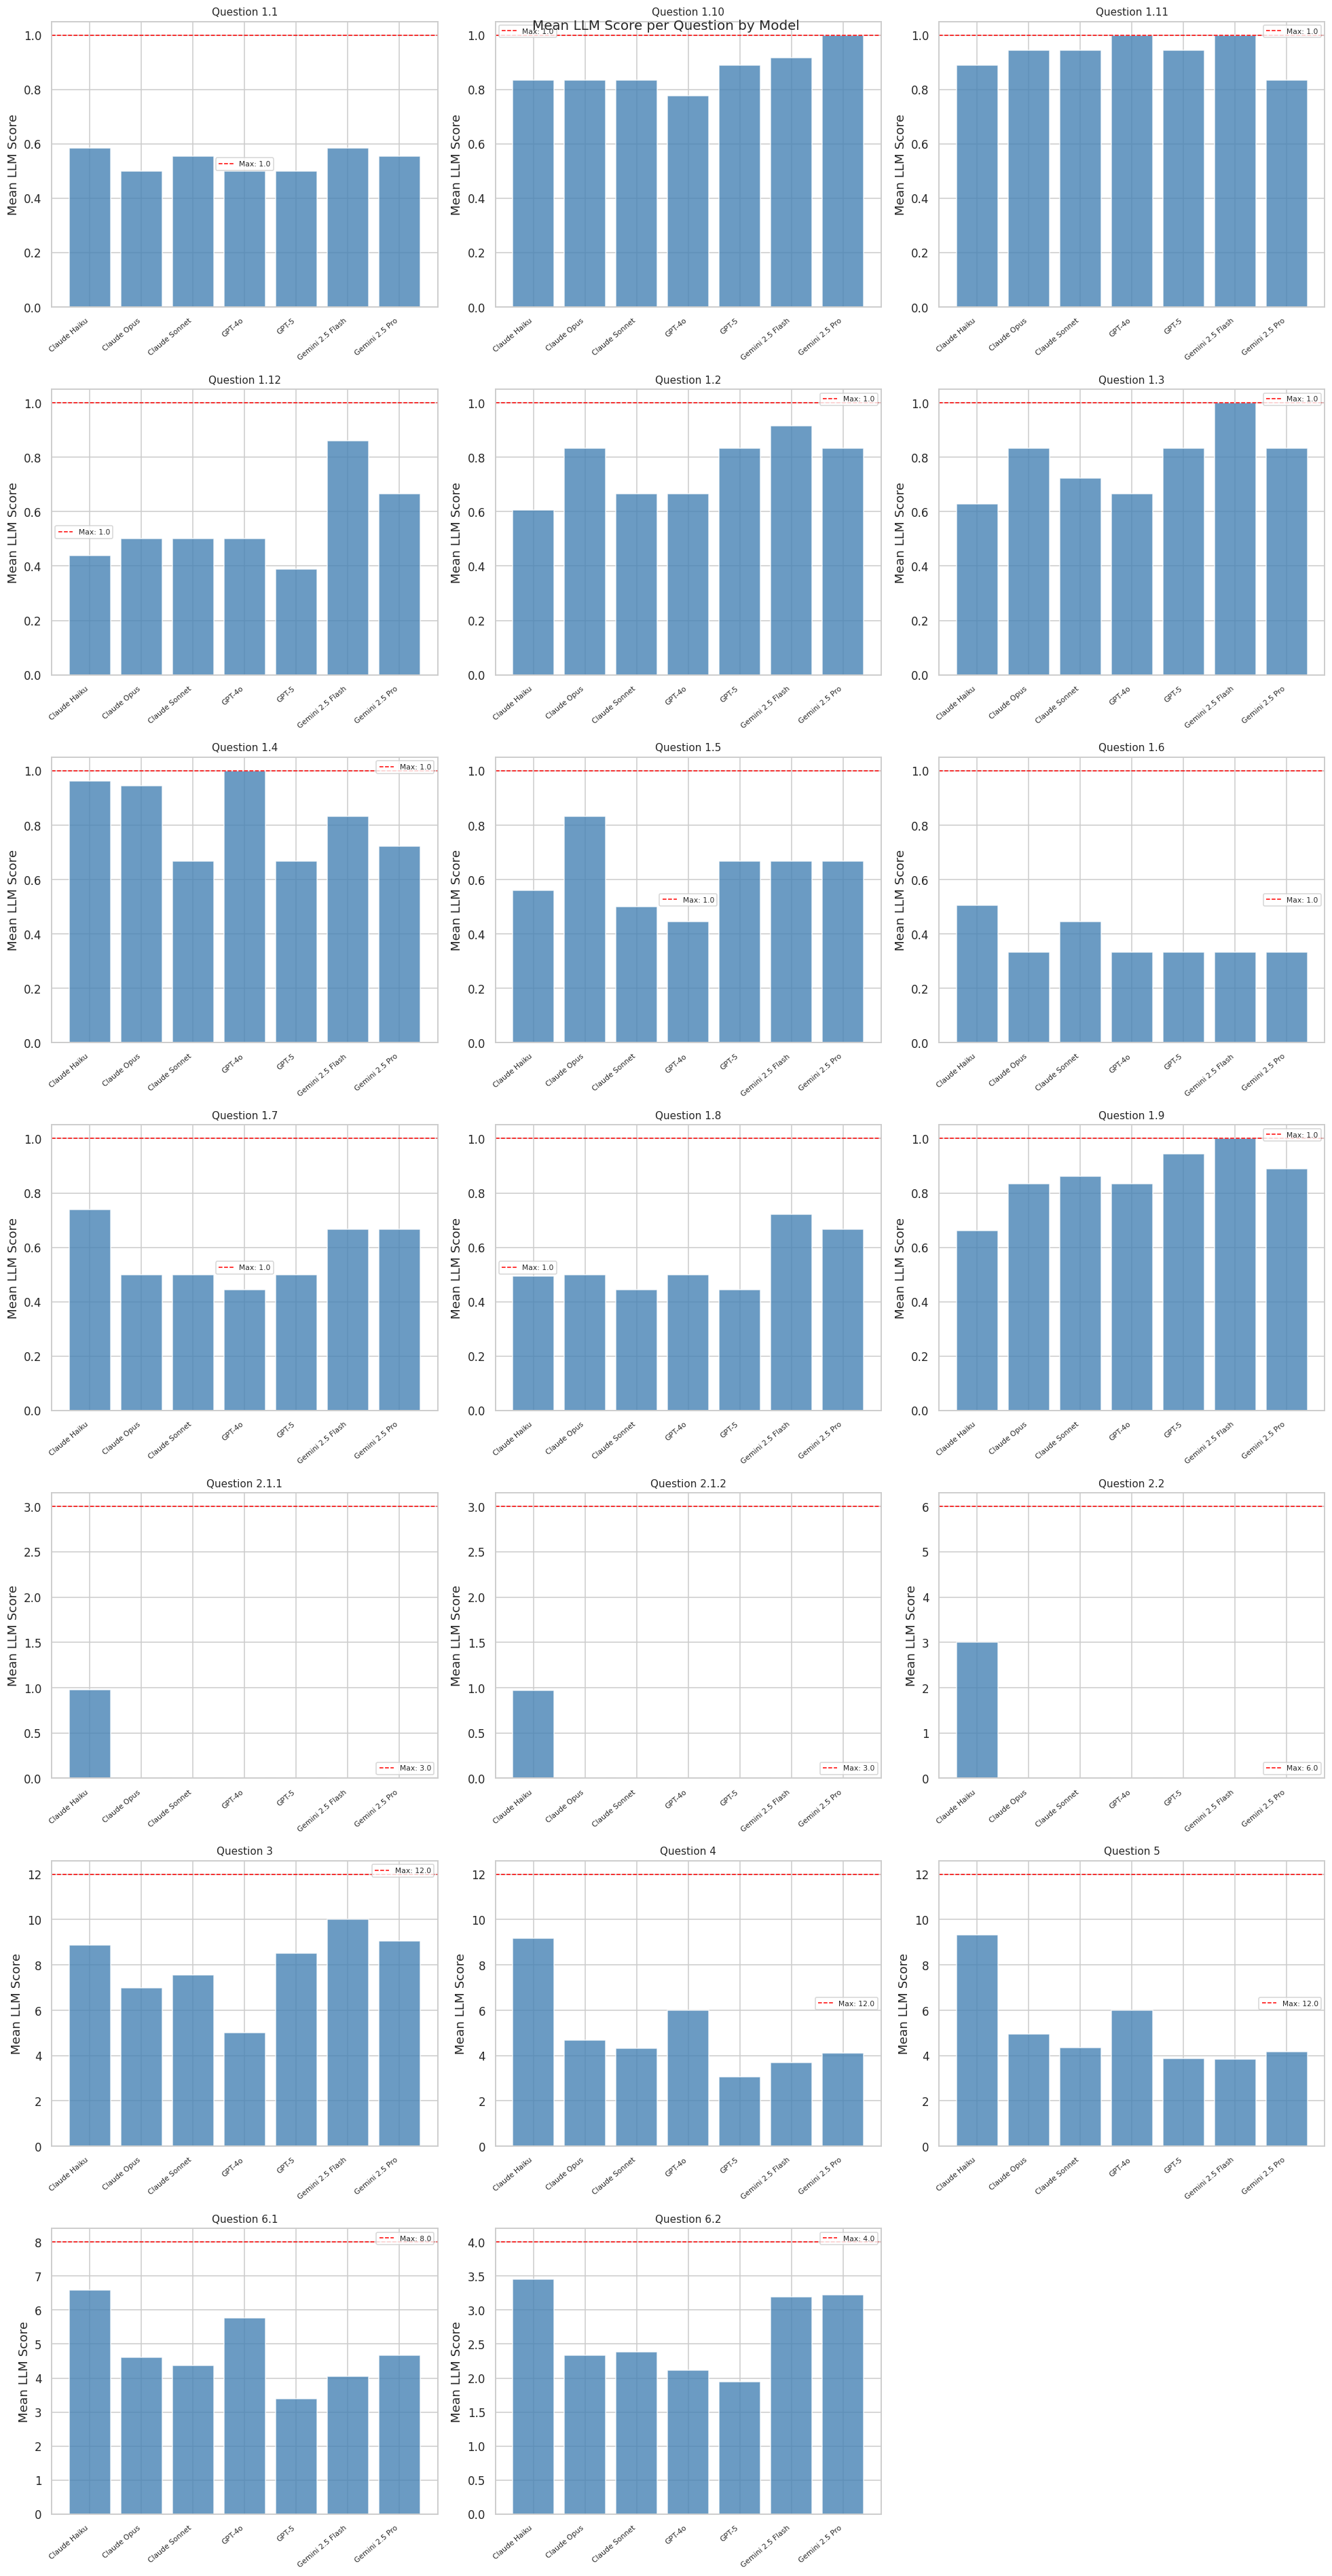

In [98]:
# 4.5 Per-question mean LLM score by model (grouped bar)
# No per-question TA data available; shows LLM scores only
questions = sorted(df_q["question"].unique())
q_means = (
    df_q.groupby(["model_label", "question"])["llm_score"]
    .mean()
    .reset_index()
)
q_max = (
    df_q.groupby("question")["max_points"]
    .first()
    .reset_index()
)

n_cols = 3
n_rows = int(np.ceil(len(questions) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for idx, q in enumerate(questions):
    ax = axes[idx]
    sub = q_means[q_means["question"] == q].sort_values("model_label")
    max_pts = q_max.loc[q_max["question"] == q, "max_points"].values
    x = np.arange(len(sub))
    bars = ax.bar(x, sub["llm_score"], color="steelblue", alpha=0.8)
    if len(max_pts):
        ax.axhline(max_pts[0], color="red", linestyle="--", linewidth=1, label=f"Max: {max_pts[0]}")
        ax.legend(fontsize=7)
    ax.set_title(f"Question {q[1:]}", fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(sub["model_label"], rotation=40, ha="right", fontsize=7)
    ax.set_ylabel("Mean LLM Score")

for j in range(len(questions), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Mean LLM Score per Question by Model", fontsize=13)
plt.tight_layout()
plt.savefig("outputs_pdf/4_5_per_question_bar.png", bbox_inches="tight")
plt.show()


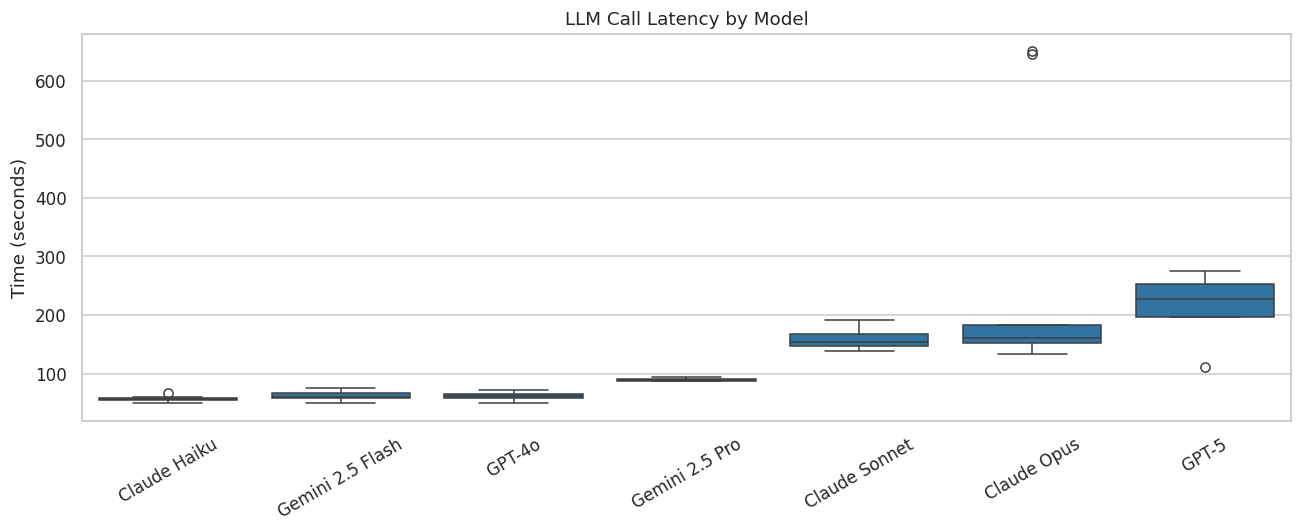

In [99]:
# 4.6 Latency boxplot per model
lat_order = df.groupby("model_label")["llm_call_time_taken"].median().sort_values().index.tolist()
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x="model_label", y="llm_call_time_taken", order=lat_order, ax=ax)
ax.set_title("LLM Call Latency by Model")
ax.set_xlabel("")
ax.set_ylabel("Time (seconds)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("outputs_pdf/4_6_latency_boxplot.png", bbox_inches="tight")
plt.show()


## Phase 5 — Agreement Metrics

For each model we compute: Pearson r, Spearman ρ, MAE, RMSE, mean bias, weighted Cohen's κ, and Bland–Altman analysis.

> **Note:** ICC (Intraclass Correlation) requires multiple raters and is not applicable here since only one TA grade is available.


In [100]:
# 5.1 Pearson, Spearman, MAE, RMSE, Bias per model
from scipy.stats import pearsonr, spearmanr

agreement_rows = []
for mlabel, grp in df.groupby("model_label"):
    sub = grp[["total_score", "ta_score"]].dropna()
    x, y = sub["total_score"].values, sub["ta_score"].values
    if len(x) < 3:
        continue
    pr, pp = pearsonr(x, y)
    sr, sp = spearmanr(x, y)
    mae  = np.mean(np.abs(x - y))
    rmse = np.sqrt(np.mean((x - y) ** 2))
    bias = np.mean(x - y)
    agreement_rows.append({
        "model": mlabel,
        "n": len(x),
        "pearson_r": round(pr, 3),
        "pearson_p": pp,
        "spearman_rho": round(sr, 3),
        "spearman_p": sp,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "mean_bias": round(bias, 2),
    })

agreement_df = pd.DataFrame(agreement_rows).sort_values("MAE")
print("=== Agreement Metrics per Model ===")

display_df = agreement_df.set_index("model").copy()
display_df["pearson_p"]  = display_df["pearson_p"].map(lambda v: f"{v:.2e}")
display_df["spearman_p"] = display_df["spearman_p"].map(lambda v: f"{v:.2e}")
display(display_df)


=== Agreement Metrics per Model ===


,n,pearson_r,pearson_p,spearman_rho,spearman_p,MAE,RMSE,mean_bias
model,,,,,,,,
Claude Haiku,9,0.807,8.55e-03,0.738,2.32e-02,7.51,8.95,-5.08
Gemini 2.5 Flash,9,-0.682,4.30e-02,-0.662,5.23e-02,21.06,21.30,-21.06
Gemini 2.5 Pro,9,-0.702,3.50e-02,-0.691,3.93e-02,21.44,21.66,-21.44
GPT-4o,9,-0.554,1.22e-01,-0.478,1.93e-01,22.78,22.95,-22.78
Claude Opus,9,0.575,1.06e-01,0.590,9.47e-02,23.39,23.44,-23.39
Claude Sonnet,9,0.273,4.77e-01,0.316,4.07e-01,24.72,24.92,-24.72
GPT-5,9,0.026,9.48e-01,0.242,5.30e-01,26.61,26.66,-26.61


In [101]:
# 5.2 Per-student LLM vs TA score breakdown per model
# With only 1 TA, ICC is not applicable. Show per-student detail instead.

student_rows = []
for mlabel, grp in df.groupby("model_label"):
    for _, row in grp.iterrows():
        student_rows.append({
            "model": mlabel,
            "pdf_id": row["pdf_id"],
            "run": row["run"],
            "llm_score": row["total_score"],
            "ta_score": row["ta_score"],
            "bias": row["llm_bias"],
        })

student_df = pd.DataFrame(student_rows)

# Mean LLM score vs TA score per student per model (averaged across runs)
student_avg = (
    student_df.groupby(["model", "pdf_id"])
    .agg(mean_llm=("llm_score", "mean"), ta_score=("ta_score", "first"), mean_bias=("bias", "mean"))
    .reset_index()
    .round(2)
)

print("=== Mean LLM Score vs TA Score per Student per Model ===")
pivot = student_avg.pivot_table(index="pdf_id", columns="model", values="mean_llm").round(2)
pivot.insert(0, "TA Score", student_avg.groupby("pdf_id")["ta_score"].first())
display(pivot)


=== Mean LLM Score vs TA Score per Student per Model ===


model,TA Score,Claude Haiku,Claude Opus,Claude Sonnet,GPT-4o,GPT-5,Gemini 2.5 Flash,Gemini 2.5 Pro
pdf_id,,,,,,,,
1,55,44.97,33.00,31.00,32.83,29.50,35.42,34.67
2,54,45.38,29.83,29.25,33.67,28.17,35.42,35.17
3,57,60.42,33.00,31.58,31.17,28.50,32.00,31.83


In [102]:
# 5.3 Weighted Cohen's κ per model
# Bin scores into grade categories (out of 72)
def score_to_grade(score, max_score=72):
    if np.isnan(score): return np.nan
    pct = score / max_score * 100
    if pct >= 90: return 4   # A
    if pct >= 80: return 3   # B
    if pct >= 70: return 2   # C
    if pct >= 60: return 1   # D
    return 0                  # F

df["llm_grade"]  = df["total_score"].apply(score_to_grade)
df["ta_grade"]   = df["ta_score"].apply(score_to_grade)

kappa_rows = []
for mlabel, grp in df.groupby("model_label"):
    sub = grp[["llm_grade", "ta_grade"]].dropna()
    if len(sub) < 3:
        continue
    try:
        kw = cohen_kappa_score(
            sub["llm_grade"].astype(int),
            sub["ta_grade"].astype(int),
            weights="quadratic",
            labels=[0, 1, 2, 3, 4]
        )
        kappa_rows.append({"model": mlabel, "weighted_kappa": round(kw, 3), "n": len(sub)})
    except Exception as e:
        kappa_rows.append({"model": mlabel, "weighted_kappa": np.nan, "n": len(sub)})

kappa_df = pd.DataFrame(kappa_rows).sort_values("weighted_kappa", ascending=False)
print("=== Weighted Cohen's κ per Model (quadratic, grade bins out of 72) ===")
print("κ > 0.8 = strong agreement, 0.6-0.8 = moderate")
display(kappa_df.set_index("model"))


=== Weighted Cohen's κ per Model (quadratic, grade bins out of 72) ===
κ > 0.8 = strong agreement, 0.6-0.8 = moderate


,weighted_kappa,n
model,,
Claude Haiku,0.0,9
Claude Opus,0.0,9
Claude Sonnet,0.0,9
GPT-4o,0.0,9
GPT-5,0.0,9
Gemini 2.5 Flash,0.0,9
Gemini 2.5 Pro,0.0,9


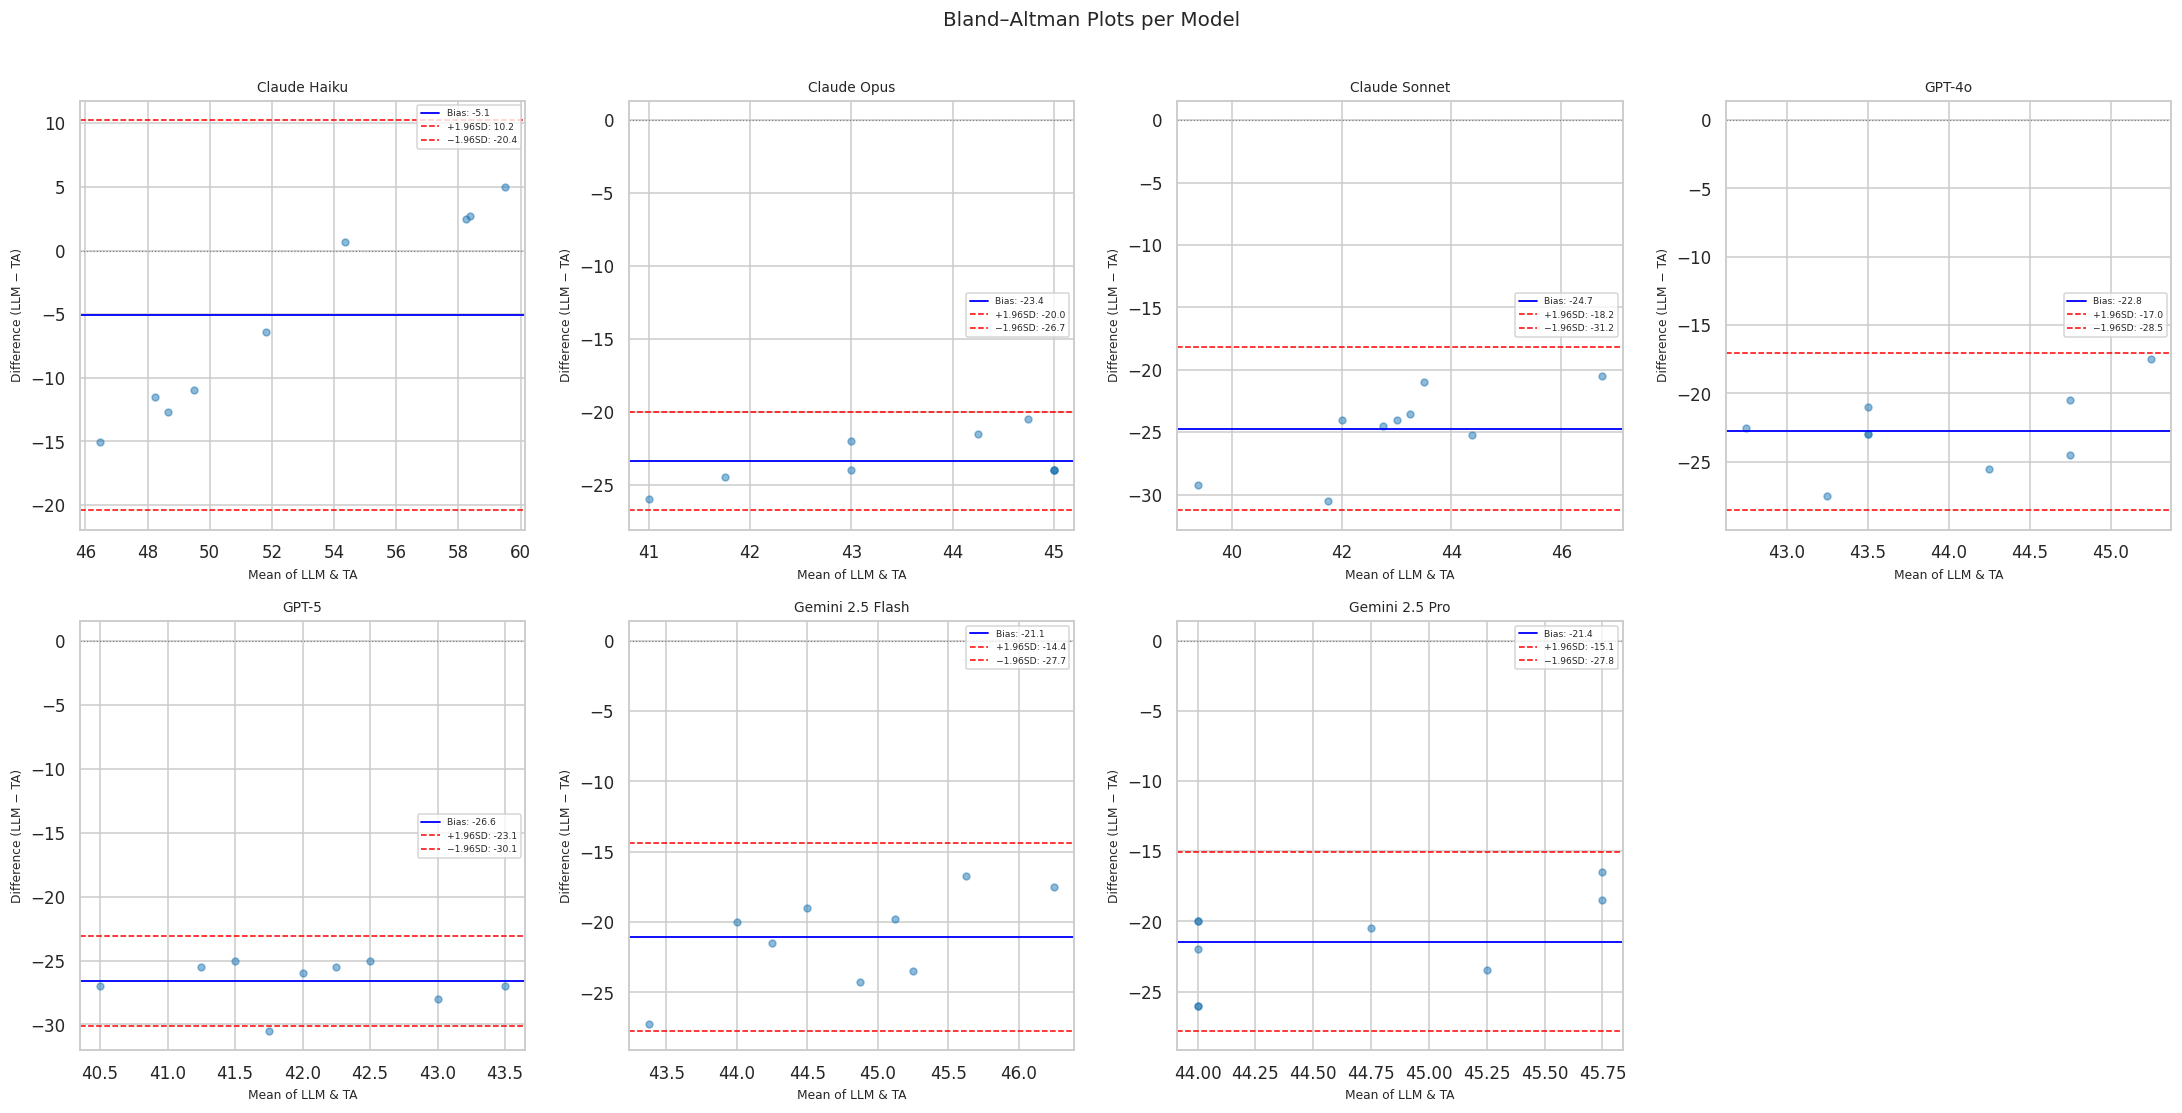

In [103]:
# 5.4 Bland–Altman plots per model
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, mlabel in enumerate(models_ordered):
    ax = axes[i]
    sub = df[df["model_label"] == mlabel][["total_score", "ta_score"]].dropna()
    mean_vals = (sub["total_score"] + sub["ta_score"]) / 2
    diff_vals = sub["total_score"] - sub["ta_score"]

    bias    = diff_vals.mean()
    sd      = diff_vals.std()
    loa_hi  = bias + 1.96 * sd
    loa_lo  = bias - 1.96 * sd

    ax.scatter(mean_vals, diff_vals, alpha=0.5, s=20)
    ax.axhline(bias,   color="blue",  linestyle="-",  linewidth=1.2,
               label=f"Bias: {bias:.1f}")
    ax.axhline(loa_hi, color="red",   linestyle="--", linewidth=1,
               label=f"+1.96SD: {loa_hi:.1f}")
    ax.axhline(loa_lo, color="red",   linestyle="--", linewidth=1,
               label=f"−1.96SD: {loa_lo:.1f}")
    ax.axhline(0, color="gray", linestyle=":", linewidth=0.8)
    ax.set_title(mlabel, fontsize=9)
    ax.set_xlabel("Mean of LLM & TA", fontsize=8)
    ax.set_ylabel("Difference (LLM − TA)", fontsize=8)
    ax.legend(fontsize=6)

for j in range(n_models, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Bland–Altman Plots per Model", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("outputs_pdf/5_4_bland_altman.png", bbox_inches="tight")
plt.show()


## Phase 6 — Outlier Detection


In [104]:
# 6.1 IQR rule on total_score and llm_bias
def iqr_outlier_flag(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)

# 6.2 Z-score flag (|z| > 3)
def zscore_flag(series):
    z = np.abs(stats.zscore(series.dropna()))
    flags = pd.Series(False, index=series.index)
    flags[series.dropna().index] = z > 3
    return flags

df["outlier_iqr_score"] = iqr_outlier_flag(df["total_score"])
df["outlier_z_score"]   = zscore_flag(df["total_score"])
df["outlier_iqr_bias"]  = iqr_outlier_flag(df["llm_bias"])
df["outlier_z_bias"]    = zscore_flag(df["llm_bias"])
df["is_outlier"]        = df[["outlier_iqr_score", "outlier_z_score",
                               "outlier_iqr_bias",  "outlier_z_bias"]].any(axis=1)

outliers = df[df["is_outlier"]][["pdf_id", "model_label", "run",
                                   "total_score", "ta_score", "llm_bias"]]
print(f"Outlier rows flagged: {len(outliers)}")
display(outliers.sort_values("llm_bias").head(20))


Outlier rows flagged: 7


,pdf_id,model_label,run,total_score,ta_score,llm_bias
33,2,Claude Haiku,1,42.50,54,-11.50
13,1,Claude Haiku,2,44.00,55,-11.00
12,1,Claude Haiku,1,48.60,55,-6.40
34,2,Claude Haiku,2,54.70,54,0.70
55,3,Claude Haiku,2,59.50,57,2.50
56,3,Claude Haiku,3,59.75,57,2.75
54,3,Claude Haiku,1,62.00,57,5.00


Outlier count per model:
model_label
Claude Haiku        7
Claude Opus         0
Claude Sonnet       0
GPT-4o              0
GPT-5               0
Gemini 2.5 Flash    0
Gemini 2.5 Pro      0


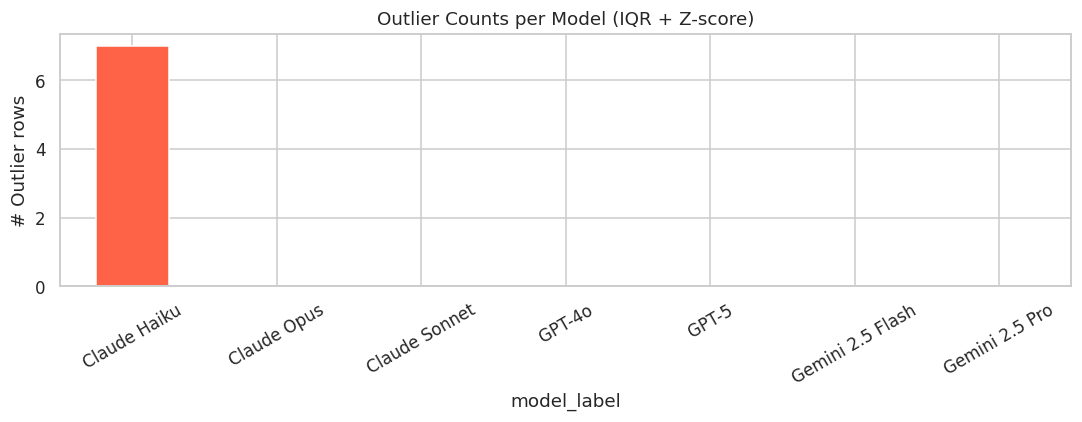

In [105]:
# 6.3 Outlier count per model
outlier_by_model = df.groupby("model_label")["is_outlier"].sum().sort_values(ascending=False)
print("Outlier count per model:")
print(outlier_by_model.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
outlier_by_model.plot(kind="bar", ax=ax, color="tomato")
ax.set_title("Outlier Counts per Model (IQR + Z-score)")
ax.set_ylabel("# Outlier rows")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("outputs_pdf/6_3_outlier_counts.png", bbox_inches="tight")
plt.show()


## Phase 7 — Statistical Tests & Model Ranking


In [106]:
# 7.1 Paired t-test & Wilcoxon signed-rank per model (H0: mean bias = 0)
from scipy.stats import ttest_rel, wilcoxon

test_rows = []
for mlabel, grp in df.groupby("model_label"):
    sub = grp[["total_score", "ta_score"]].dropna()
    x, y = sub["total_score"].values, sub["ta_score"].values
    if len(x) < 3:
        continue
    t_stat, t_p   = ttest_rel(x, y)
    try:
        w_stat, w_p = wilcoxon(x - y)
    except ValueError:
        w_stat, w_p = np.nan, np.nan

    test_rows.append({
        "model": mlabel,
        "n": len(x),
        "t_stat": round(t_stat, 3),
        "t_p": round(t_p, 4),
        "wilcoxon_stat": round(w_stat, 1) if not np.isnan(w_stat) else np.nan,
        "wilcoxon_p": round(w_p, 4) if not np.isnan(w_p) else np.nan,
        "bias_sig": "YES" if t_p < 0.05 else "no",
    })

tests_df = pd.DataFrame(test_rows).sort_values("t_p")
print("=== Paired Tests: Is LLM bias significantly ≠ 0? ===")
display(tests_df.set_index("model"))


=== Paired Tests: Is LLM bias significantly ≠ 0? ===


,n,t_stat,t_p,wilcoxon_stat,wilcoxon_p,bias_sig
model,,,,,,
Claude Opus,9,-41.037,0.0000,0.0,0.0039,YES
Claude Sonnet,9,-22.308,0.0000,0.0,0.0039,YES
GPT-4o,9,-23.258,0.0000,0.0,0.0039,YES
GPT-5,9,-44.813,0.0000,0.0,0.0039,YES
Gemini 2.5 Pro,9,-19.827,0.0000,0.0,0.0039,YES
Gemini 2.5 Flash,9,-18.529,0.0000,0.0,0.0039,YES
Claude Haiku,9,-1.948,0.0873,10.0,0.1641,no


In [107]:
# 7.2 One-way ANOVA: does MAE differ across models?
from scipy.stats import f_oneway

anova_groups = [grp["llm_abs_error"].dropna().values
                for _, grp in df.groupby("model_label")]
f_stat, anova_p = f_oneway(*anova_groups)
print(f"One-way ANOVA on MAE across models: F={f_stat:.3f}, p={anova_p:.4f}")
if anova_p < 0.05:
    print("→ Significant difference in MAE between models (p < 0.05). Running Tukey HSD...")
else:
    print("→ No significant difference between models.")


One-way ANOVA on MAE across models: F=33.250, p=0.0000
→ Significant difference in MAE between models (p < 0.05). Running Tukey HSD...


In [108]:
# 7.3 Tukey HSD post-hoc test (if ANOVA is significant)
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df["llm_abs_error"].dropna(),
    groups=df.loc[df["llm_abs_error"].notna(), "model_label"],
    alpha=0.05
)
print(tukey.summary())


           Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1           group2      meandiff p-adj   lower    upper  reject
-------------------------------------------------------------------------
    Claude Haiku      Claude Opus  15.8778    0.0  11.1709 20.5846   True
    Claude Haiku    Claude Sonnet  17.2111    0.0  12.5043  21.918   True
    Claude Haiku           GPT-4o  15.2667    0.0  10.5598 19.9735   True
    Claude Haiku            GPT-5     19.1    0.0  14.3932 23.8068   True
    Claude Haiku Gemini 2.5 Flash  13.5444    0.0   8.8376 18.2513   True
    Claude Haiku   Gemini 2.5 Pro  13.9333    0.0   9.2265 18.6402   True
     Claude Opus    Claude Sonnet   1.3333 0.9761  -3.3735  6.0402  False
     Claude Opus           GPT-4o  -0.6111 0.9997   -5.318  4.0957  False
     Claude Opus            GPT-5   3.2222 0.3707  -1.4846  7.9291  False
     Claude Opus Gemini 2.5 Flash  -2.3333 0.7342  -7.0402  2.3735  False
     Claude Opus   Gemini 2.5 Pro  -1.

In [109]:
# 7.4 Final Model Ranking Table
# Combine all metrics: lower MAE/RMSE/|bias| is better; higher pearson_r/kappa is better

ranking = (
    agreement_df[["model", "pearson_r", "MAE", "RMSE", "mean_bias"]]
    .merge(kappa_df[["model", "weighted_kappa"]], on="model", how="left")
    .merge(
        df.groupby("model_label")["llm_call_time_taken"].median()
          .reset_index().rename(columns={"model_label": "model", "llm_call_time_taken": "median_latency_s"}),
        on="model", how="left"
    )
)

# Composite rank: rank each metric and average (lower rank = better)
ranking["rank_MAE"]    = ranking["MAE"].rank()
ranking["rank_r"]      = ranking["pearson_r"].rank(ascending=False)
ranking["rank_kappa"]  = ranking["weighted_kappa"].rank(ascending=False)
ranking["rank_bias"]   = ranking["mean_bias"].abs().rank()
ranking["rank_latency"]= ranking["median_latency_s"].rank()
ranking["composite_rank"] = (
    ranking[["rank_MAE", "rank_r", "rank_kappa", "rank_bias"]].mean(axis=1)
)
ranking = ranking.sort_values("composite_rank")

print("=== Final Model Ranking (lower composite rank = better alignment with TA) ===")
display(ranking.set_index("model")[[
    "pearson_r", "MAE", "RMSE", "mean_bias",
    "weighted_kappa", "median_latency_s", "composite_rank"
]].round(3))


=== Final Model Ranking (lower composite rank = better alignment with TA) ===


,pearson_r,MAE,RMSE,mean_bias,weighted_kappa,median_latency_s,composite_rank
model,,,,,,,
Claude Haiku,0.807,7.51,8.95,-5.08,0.0,56.653,1.75
Gemini 2.5 Flash,-0.682,21.06,21.30,-21.06,0.0,60.813,3.50
Claude Opus,0.575,23.39,23.44,-23.39,0.0,160.308,4.00
Gemini 2.5 Pro,-0.702,21.44,21.66,-21.44,0.0,88.881,4.25
GPT-4o,-0.554,22.78,22.95,-22.78,0.0,62.688,4.25
Claude Sonnet,0.273,24.72,24.92,-24.72,0.0,154.005,4.75
GPT-5,0.026,26.61,26.66,-26.61,0.0,226.774,5.50


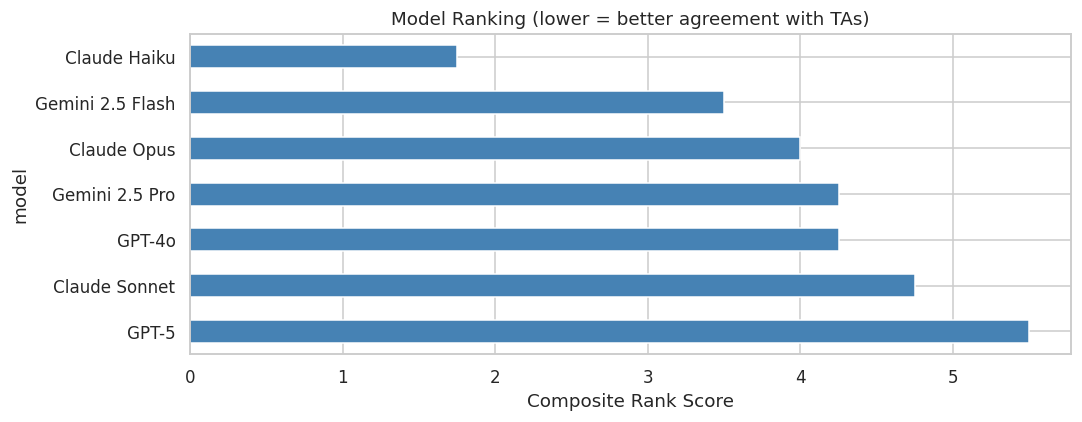

In [110]:
# 7.5 Ranking bar chart (composite rank)
fig, ax = plt.subplots(figsize=(10, 4))
ranking_plot = ranking.set_index("model")["composite_rank"].sort_values()
ranking_plot.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Model Ranking (lower = better agreement with TAs)")
ax.set_xlabel("Composite Rank Score")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("outputs_pdf/7_5_model_ranking.png", bbox_inches="tight")
plt.show()


## Phase 8 — Per-Question Deep Dive

Per-question TA grades are not available — only the overall TA total score exists.  
This phase analyses LLM per-question scoring patterns: mean scores, score variance across runs, and inter-model agreement per question.


In [111]:
# 8.1 Per-question mean LLM score and score utilisation (% of max_points)
q_stats = (
    df_q.groupby(["model_label", "question"])
    .agg(
        mean_score=("llm_score", "mean"),
        std_score=("llm_score", "std"),
        max_points=("max_points", "first"),
    )
    .reset_index()
)
q_stats["pct_max"] = (q_stats["mean_score"] / q_stats["max_points"] * 100).round(1)

# Pivot: mean score by question × model
score_pivot = q_stats.pivot_table(index="model_label", columns="question", values="mean_score")
print("=== Per-Question Mean LLM Score (rows=models, columns=questions) ===")
display(score_pivot.round(2))


=== Per-Question Mean LLM Score (rows=models, columns=questions) ===


question,Q1.1,Q1.10,Q1.11,Q1.12,Q1.2,Q1.3,Q1.4,Q1.5,Q1.6,Q1.7,Q1.8,Q1.9,Q2.1.1,Q2.1.2,Q2.2,Q3,Q4,Q5,Q6.1,Q6.2
model_label,,,,,,,,,,,,,,,,,,,,
Claude Haiku,0.58,0.83,0.89,0.44,0.61,0.63,0.96,0.56,0.51,0.74,0.49,0.66,0.98,0.97,3.0,8.89,9.17,9.31,6.59,3.46
Claude Opus,0.50,0.83,0.94,0.50,0.83,0.83,0.94,0.83,0.33,0.50,0.50,0.83,0.00,0.00,0.0,7.00,4.67,4.94,4.61,2.33
Claude Sonnet,0.56,0.83,0.94,0.50,0.67,0.72,0.67,0.50,0.44,0.50,0.44,0.86,0.00,0.00,0.0,7.56,4.31,4.36,4.36,2.39
GPT-4o,0.50,0.78,1.00,0.50,0.67,0.67,1.00,0.44,0.33,0.44,0.50,0.83,0.00,0.00,0.0,5.00,6.00,6.00,5.78,2.11
GPT-5,0.50,0.89,0.94,0.39,0.83,0.83,0.67,0.67,0.33,0.50,0.44,0.94,0.00,0.00,0.0,8.53,3.06,3.86,3.39,1.94
Gemini 2.5 Flash,0.58,0.92,1.00,0.86,0.92,1.00,0.83,0.67,0.33,0.67,0.72,1.00,0.00,0.00,0.0,10.00,3.69,3.83,4.06,3.19
Gemini 2.5 Pro,0.56,1.00,0.83,0.67,0.83,0.83,0.72,0.67,0.33,0.67,0.67,0.89,0.00,0.00,0.0,9.06,4.11,4.17,4.67,3.22


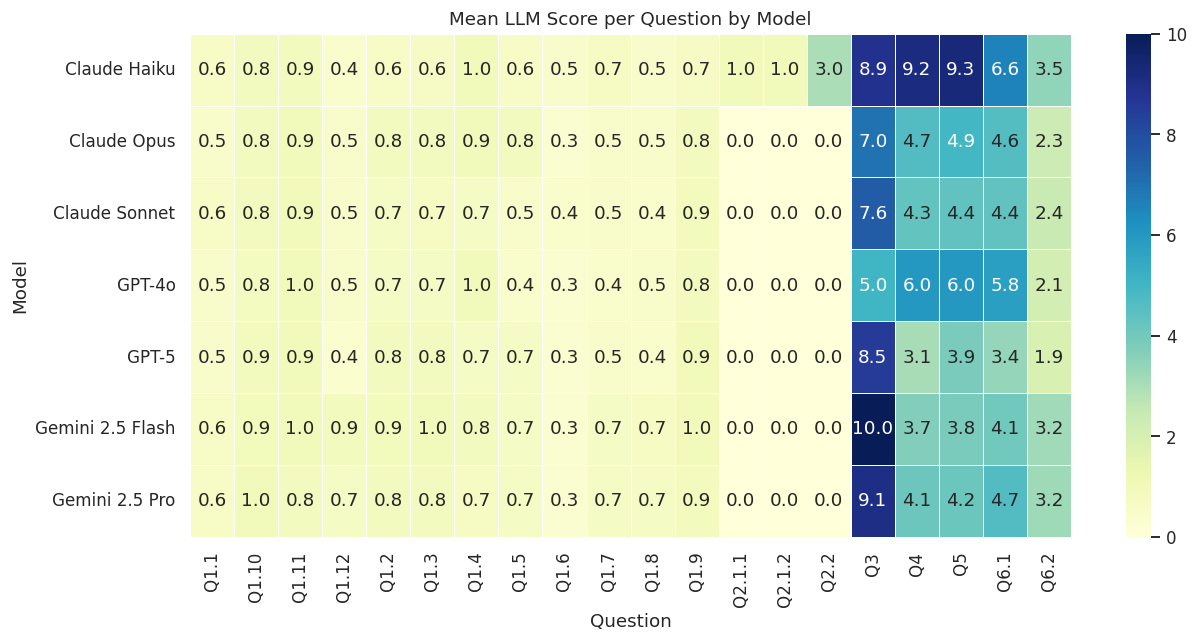

In [112]:
# 8.2 Heatmap: mean LLM score per question × model
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(score_pivot, annot=True, fmt=".1f", cmap="YlGnBu",
            linewidths=0.5, ax=ax)
ax.set_title("Mean LLM Score per Question by Model")
ax.set_xlabel("Question")
ax.set_ylabel("Model")
plt.tight_layout()
plt.savefig("outputs_pdf/8_2_per_question_score_heatmap.png", bbox_inches="tight")
plt.show()


In [113]:
# 8.3 Per-question run consistency: std of LLM score across 3 runs per (model, student, question)
run_std = (
    df_q.groupby(["model_label", "pdf_id", "question"])["llm_score"]
    .std()
    .reset_index()
    .rename(columns={"llm_score": "run_std"})
)
consistency_pivot = run_std.groupby(["model_label", "question"])["run_std"].mean().unstack("question")

print("=== Mean Run-to-Run Std per Question (lower = more consistent across runs) ===")
display(consistency_pivot.round(3))


=== Mean Run-to-Run Std per Question (lower = more consistent across runs) ===


question,Q1.1,Q1.10,Q1.11,Q1.12,Q1.2,Q1.3,Q1.4,Q1.5,Q1.6,Q1.7,Q1.8,Q1.9,Q2.1.1,Q2.1.2,Q2.2,Q3,Q4,Q5,Q6.1,Q6.2
model_label,,,,,,,,,,,,,,,,,,,,
Claude Haiku,0.000,0.038,0.192,0.169,0.077,0.052,0.042,0.096,0.140,0.048,0.048,0.010,0.038,0.058,0.778,1.141,1.567,0.969,0.601,0.184
Claude Opus,0.000,0.000,0.096,0.000,0.000,0.000,0.096,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.447,0.543,0.539,0.096,0.000
Claude Sonnet,0.096,0.000,0.096,0.000,0.000,0.192,0.000,0.192,0.096,0.000,0.096,0.048,0.000,0.000,0.000,0.481,1.401,0.817,0.307,0.359
GPT-4o,0.000,0.096,0.000,0.000,0.000,0.000,0.000,0.192,0.000,0.096,0.000,0.192,0.000,0.000,0.000,0.894,0.000,0.000,0.770,0.192
GPT-5,0.000,0.096,0.096,0.096,0.000,0.000,0.192,0.000,0.000,0.000,0.096,0.096,0.000,0.000,0.000,0.767,0.263,0.428,0.359,0.385
Gemini 2.5 Flash,0.096,0.000,0.000,0.131,0.144,0.000,0.000,0.000,0.000,0.000,0.096,0.000,0.000,0.000,0.000,0.351,0.478,0.385,0.674,0.241
Gemini 2.5 Pro,0.096,0.000,0.000,0.000,0.000,0.000,0.096,0.000,0.000,0.000,0.000,0.096,0.000,0.000,0.000,0.704,0.936,0.455,0.806,0.385


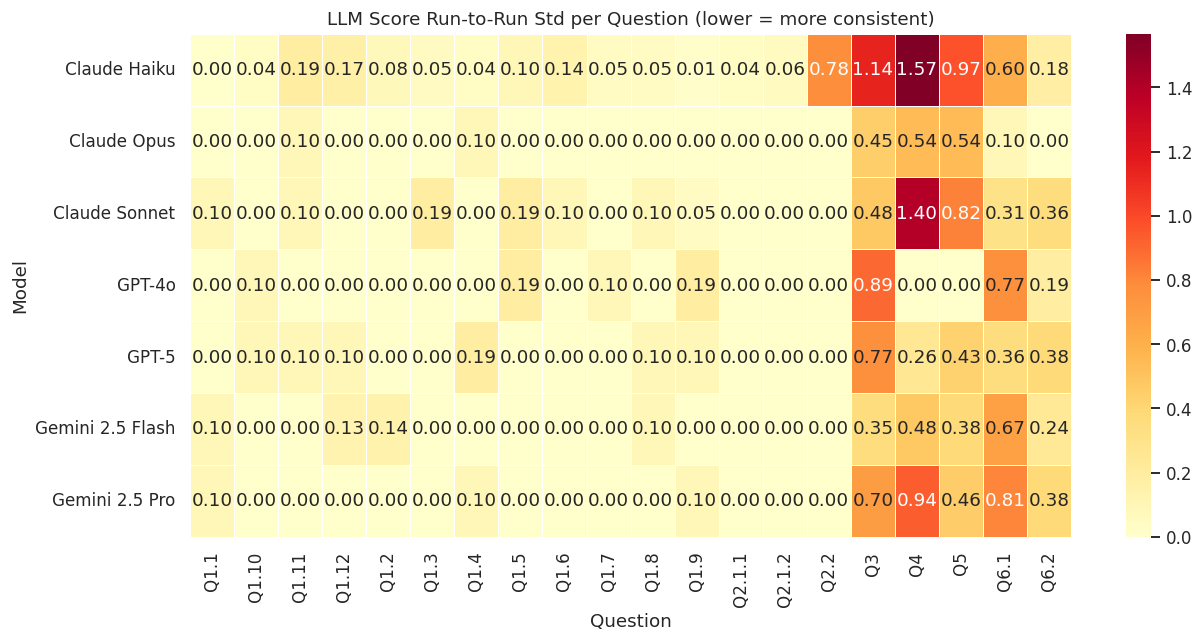

In [114]:
# 8.4 Heatmap: run consistency (std) per question × model
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(consistency_pivot, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, ax=ax)
ax.set_title("LLM Score Run-to-Run Std per Question (lower = more consistent)")
ax.set_xlabel("Question")
ax.set_ylabel("Model")
plt.tight_layout()
plt.savefig("outputs_pdf/8_4_per_question_consistency_heatmap.png", bbox_inches="tight")
plt.show()


## Save Outputs


In [115]:
# Save cleaned dataset and key result tables
cleaned_cols = [
    "pdf_id", "model", "model_label", "run",
    "total_score", "total_points", "norm_score",
    "ta_score", "llm_bias", "llm_abs_error",
    "llm_grade", "ta_grade", "is_outlier", "llm_call_time_taken",
]
df[cleaned_cols].to_csv("outputs_pdf/cleaned_sample.csv", index=False)
print("Saved: outputs_pdf/cleaned_sample.csv")

ranking.to_csv("outputs_pdf/model_ranking.csv", index=False)
print("Saved: outputs_pdf/model_ranking.csv")

q_stats.to_csv("outputs_pdf/per_question_llm_stats.csv", index=False)
print("Saved: outputs_pdf/per_question_llm_stats.csv")

print("\nAll outputs saved to outputs_pdf/")
print("Plots saved:")
import glob
for f in sorted(glob.glob("outputs_pdf/*.png")):
    print(" ", f)


Saved: outputs_pdf/cleaned_sample.csv
Saved: outputs_pdf/model_ranking.csv
Saved: outputs_pdf/per_question_llm_stats.csv

All outputs saved to outputs_pdf/
Plots saved:
  outputs_pdf/4_1_score_distributions.png
  outputs_pdf/4_2_llm_vs_ta_scatter.png
  outputs_pdf/4_3_bias_boxplot.png
  outputs_pdf/4_4_correlation_heatmap.png
  outputs_pdf/4_5_per_question_bar.png
  outputs_pdf/4_6_latency_boxplot.png
  outputs_pdf/5_4_bland_altman.png
  outputs_pdf/6_3_outlier_counts.png
  outputs_pdf/7_5_model_ranking.png
  outputs_pdf/8_2_per_question_score_heatmap.png
  outputs_pdf/8_4_per_question_consistency_heatmap.png
